Imports

In [3]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import RobustScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

import joblib

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)


Load Dataset

In [4]:
df = pd.read_csv("../datasets/processed/D6_kmeans_ready.csv")

print("Dataset Loaded Successfully")
print("Shape:", df.shape)

Dataset Loaded Successfully
Shape: (119398, 144)


Dataset Overview

In [5]:
df.head()

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 119398 entries, 0 to 119397
Columns: 144 entries, latitude to season_3
dtypes: bool(110), float64(20), int64(14)
memory usage: 43.5 MB


Select Clustering Features

In [7]:
clustering_features = [
    "temperature_celsius",
    "humidity",
    "pressure_mb",
    "precip_mm",
    "cloud",
    "uv_index",
    "visibility_km",
    "air_quality_PM2.5",
    "air_quality_PM10",
    "air_quality_Carbon_Monoxide",
    "air_quality_Ozone",
    "air_quality_Nitrogen_dioxide",
    "air_quality_Sulphur_dioxide",
    "day_length_minutes",
    "temperature_gap",
]
X = df[clustering_features]

print(X.shape)

(119398, 15)


Scale Features

In [8]:
cluster_scaler = RobustScaler()

X_scaled = cluster_scaler.fit_transform(X)

print(X_scaled.shape)

(119398, 15)


Save Clustering Scaler

In [ ]:
joblib.dump(cluster_scaler, "../models/clustering_scaler.pkl")

print("Clustering scaler saved")

Clustering scaler saved


Elbow Method

In [10]:
inertia = []

k_values = range(2, 11)

for k in k_values:

    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    model.fit(X_scaled)

    inertia.append(model.inertia_)


Plot Elbow Curve

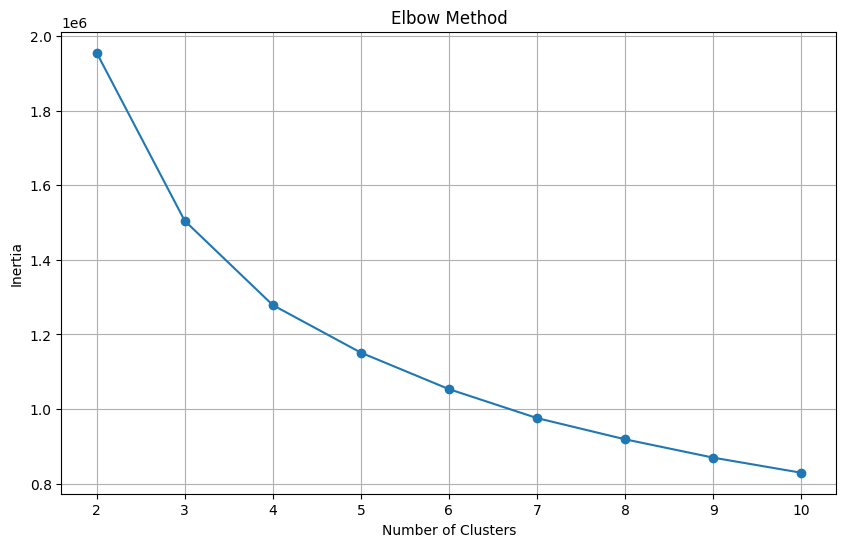

In [11]:
plt.figure(figsize=(10, 6))

plt.plot(k_values, inertia, marker="o")

plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.title("Elbow Method")

plt.grid()

plt.show()

Silhouette Scores

In [13]:
silhouette_scores = []

for k in range(2, 11):

    model = KMeans(n_clusters=k, random_state=42, n_init=10)

    labels = model.fit_predict(X_scaled)

    sample_size = min(10000, len(X_scaled))

    score = silhouette_score(
    X_scaled,
    labels,
    sample_size=sample_size,
    random_state=42
    )


    silhouette_scores.append(score)

    print(f"K={k} | Silhouette Score={score:.4f}")

K=2 | Silhouette Score=0.5046
K=3 | Silhouette Score=0.4996
K=4 | Silhouette Score=0.3447
K=5 | Silhouette Score=0.3362
K=6 | Silhouette Score=0.2568
K=7 | Silhouette Score=0.2450
K=8 | Silhouette Score=0.2522
K=9 | Silhouette Score=0.2476
K=10 | Silhouette Score=0.2168


Plot Silhouette Scores

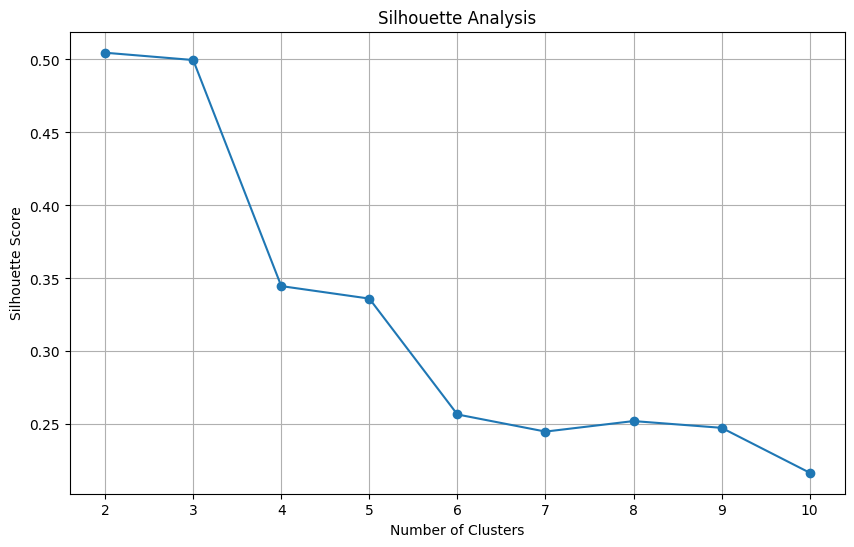

In [14]:
plt.figure(figsize=(10, 6))

plt.plot(range(2, 11), silhouette_scores, marker="o")

plt.xlabel("Number of Clusters")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Analysis")

plt.grid()

plt.show()

Choose Best K

In [15]:
optimal_k = 4

Train Final KMeans

In [16]:
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)

df["climate_cluster"] = kmeans.fit_predict(X_scaled)

print(df["climate_cluster"].value_counts())

climate_cluster
0    76403
1    22459
2    19162
3     1374
Name: count, dtype: int64


C:\Users\ANAMIKA\AppData\Local\Temp\ipykernel_16216\4081590998.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["climate_cluster"] = kmeans.fit_predict(X_scaled)


Cluster Centers

In [17]:
centers = pd.DataFrame(kmeans.cluster_centers_, columns=clustering_features)

centers

,temperature_celsius,humidity,pressure_mb,precip_mm,cloud,uv_index,visibility_km,air_quality_PM2.5,air_quality_PM10,air_quality_Carbon_Monoxide,air_quality_Ozone,air_quality_Nitrogen_dioxide,air_quality_Sulphur_dioxide,day_length_minutes,temperature_gap
0,-0.061927,-0.093540,-0.127963,0.084442,0.362722,0.107458,-0.055535,-0.046072,-0.066569,-0.076144,0.200124,-0.047828,0.093002,0.079309,0.309552
1,0.082788,0.411462,-0.014471,0.148883,0.750239,0.074758,-6.823919,0.266850,0.276657,0.421414,0.031617,0.423374,0.694146,0.108129,0.694653
2,-0.529719,-0.328666,0.345170,0.009406,0.068881,0.008506,-0.025732,1.884829,1.848966,1.738586,-0.166059,1.327449,1.242115,-0.533558,0.051409
3,0.094456,0.055615,0.049733,0.067999,0.348472,0.048035,-4.468996,3.365174,3.694978,6.030911,-0.529945,5.816535,16.861300,-0.072712,0.507584


Convert Centers Back To Original Scale

In [18]:
centers_original = pd.DataFrame(
    cluster_scaler.inverse_transform(kmeans.cluster_centers_),
    columns=clustering_features,
)

centers_original

,temperature_celsius,humidity,pressure_mb,precip_mm,cloud,uv_index,visibility_km,air_quality_PM2.5,air_quality_PM10,air_quality_Carbon_Monoxide,air_quality_Ozone,air_quality_Nitrogen_dioxide,air_quality_Sulphur_dioxide,day_length_minutes,temperature_gap
0,20.686010,59.164852,1012.232219,0.084442,22.508861,1.107458,9.944465,56.582480,69.122815,542.164640,48.145486,9.344753,4.002213,695.075783,0.588150
1,21.887137,79.869941,1012.913175,0.148883,38.009573,1.074758,3.176081,83.869344,102.518754,794.625460,40.697462,15.800218,7.248390,696.920255,1.319841
2,16.803329,49.524709,1015.071022,0.009406,10.755258,1.008506,9.974268,224.957110,255.504399,1462.958430,31.960194,28.186051,10.207421,655.852320,0.097678
3,21.983988,65.280204,1013.298399,0.067999,21.938865,1.048035,5.531004,354.043159,435.121325,3640.883988,15.876419,89.686536,94.551019,685.346434,0.964410


Cluster Statistics

In [19]:
cluster_summary = df.groupby("climate_cluster")[clustering_features].mean()

cluster_summary

,temperature_celsius,humidity,pressure_mb,precip_mm,cloud,uv_index,visibility_km,air_quality_PM2.5,air_quality_PM10,air_quality_Carbon_Monoxide,air_quality_Ozone,air_quality_Nitrogen_dioxide,air_quality_Sulphur_dioxide,day_length_minutes,temperature_gap
climate_cluster,,,,,,,,,,,,,,,
0,20.686029,59.165072,1012.232268,0.084441,22.508658,1.107457,9.944466,56.582825,69.123169,542.166018,48.145483,9.344963,4.002470,695.075429,0.588173
1,21.887137,79.869941,1012.913175,0.148883,38.009573,1.074758,3.176081,83.869344,102.518754,794.625460,40.697462,15.800218,7.248390,696.920255,1.319841
2,16.803048,49.523327,1015.070974,0.009407,10.755454,1.008506,9.974267,224.964518,255.512713,1463.000986,31.959362,28.186197,10.206722,655.851686,0.097558
3,21.983988,65.280204,1013.298399,0.067999,21.938865,1.048035,5.531004,354.043159,435.121325,3640.883988,15.876419,89.686536,94.551019,685.346434,0.964410


Interpret Clusters

Look at:

Highest precip_mm
Highest humidity
Highest cloud

→ Flood-Prone

Highest temperature
Highest UV
Highest temperature_gap

→ Heatwave-Prone

Highest PM2.5
Highest PM10
Highest CO

→ Pollution-Prone

Moderate values everywhere

→ Moderate


Create Cluster Mapping

In [21]:
cluster_mapping = {
    0: "Moderate",
    1: "Flood-Prone",
    2: "Heatwave-Prone",
    3: "Pollution-Prone",
}

Create Climate Profile Column

In [22]:
df["climate_profile"] = df["climate_cluster"].map(cluster_mapping)

df[["climate_cluster", "climate_profile"]].head()

C:\Users\ANAMIKA\AppData\Local\Temp\ipykernel_16216\1195038606.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["climate_profile"] = (


,climate_cluster,climate_profile
0,0,Moderate
1,0,Moderate
2,0,Moderate
3,0,Moderate
4,0,Moderate


Climate Profile Distribution

In [23]:
print(df["climate_profile"].value_counts())

climate_profile
Moderate           76403
Flood-Prone        22459
Heatwave-Prone     19162
Pollution-Prone     1374
Name: count, dtype: int64


Visualize Climate Profiles

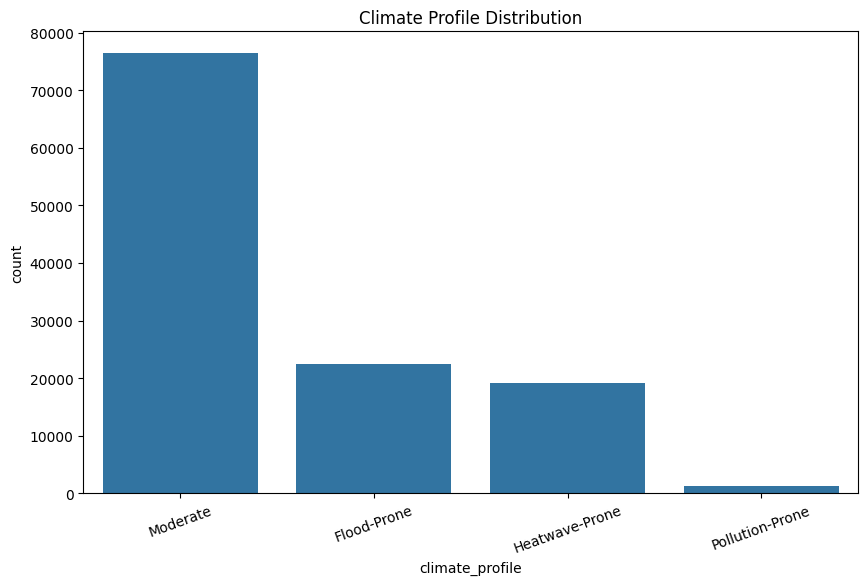

In [24]:
plt.figure(figsize=(10, 6))

sns.countplot(x="climate_profile", data=df)

plt.title("Climate Profile Distribution")

plt.xticks(rotation=20)

plt.show()

Save KMeans Model

In [25]:
joblib.dump(kmeans, "../models/kmeans_climate_profile.pkl")

print("KMeans model saved")

KMeans model saved


Save Dataset

In [27]:
df.to_csv("../datasets/processed/climate_profiles.csv", index=False)

print("dataset saved successfully")

dataset saved successfully


Verification

In [28]:
saved_df = pd.read_csv("../datasets/processed/climate_profiles.csv")

print(saved_df.shape)

print(
    saved_df["climate_profile"]
    .value_counts()
)

(119398, 146)
climate_profile
Moderate           76403
Flood-Prone        22459
Heatwave-Prone     19162
Pollution-Prone     1374
Name: count, dtype: int64


 Climate Profile Discovery Report

In [31]:
print("""

CLIMATE PROFILE DISCOVERY REPORT

Algorithm:
KMeans Clustering

Cluster Selection:
Elbow Method
Silhouette Score

Final K:
4

Climate Profiles:

1. Flood-Prone

2. Heatwave-Prone

3. Pollution-Prone

4. Moderate

Artifacts Saved:

kmeans_climate_profile.pkl

clustering_scaler.pkl

Dataset Output:

climate_profiles.csv

Completed Successfully

""")




CLIMATE PROFILE DISCOVERY REPORT

Algorithm:
KMeans Clustering

Cluster Selection:
Elbow Method
Silhouette Score

Final K:
4

Climate Profiles:

1. Flood-Prone

2. Heatwave-Prone

3. Pollution-Prone

4. Moderate

Artifacts Saved:

kmeans_climate_profile.pkl

clustering_scaler.pkl

Dataset Output:

climate_profiles.csv

Completed Successfully


